# CS-345 Term Project 
Dacovney Brochu and Nuri Shawesh

## Project Overview

#### Goal
In this project we used a sythentic dataset that covers the process of chocolate sales around the world. The goal of of this project was to investigate and experiment how well the Random Forests model does in predicting wheater a chocolate sale has the chance of being high profit or not. We also experimented with a Gradient Boosting model to observe how it does while changing various hyperparamters. Our goal throughout this project was to learn how to properly manipulate our dataset and explain the "why" behind our choices. We also set a goal to experiment various ways we can tune our Gradient Boosting model and observe the accuracy. As well as understand the role behind tuning and what the adjustments mean for the results.

#### Data Set Description
[Chocolate Sales Dataset 2023-2024](https://www.kaggle.com/datasets/ssssws/chocolate-sales-dataset-2023-2024?select=calendar.csv) 
The data will help us recognize wheather a chocolate product has potential to be high profit or not. Using machine learning to solve this can help a store owner figure out what products are worth keeping/continue purchasing in bulk based on historical sale trends. Regardless of time of year, country, and type of store the store owner can be confident in knowing that purchasing a certain chocolate product in bulk has better chances of increasing profits compared to other products. This would effectively help a store owner recognize bottle necks in sales and readjust cost on supply in future purchases for the store. 

The data is stored as a csv in 5 different files. Each file represents an independent category which are **sales, stores, products, customers, calendar** 

**Sales.csv:** Is a 11 column dataset that contains 1000000 unique values. This is our biggest csv out of the bunch. It contains 11 features which are as follows: 
* order_id – Unique order identifier
* order_date – Date of purchase
* product_id – Product identifier
* store_id – Store identifier
* customer_id – Customer identifier
* quantity – Number of items sold
* unit_price – Price per unit
* discount – Discount applied to the transaction
* revenue – Total revenue after discount
* cost – Estimated product cost
* profit – Profit from the transaction

**Stores.csv** Is a 5 feature dataset. The features are as follows:
* store_id - Unique store identifier
* store_name - Name of the store
* city - City store is located
* country - Country store is located
* store_type - Type of store

**Products.csv** Is a 6 feature dataset. The features are as follows:
* product_id - Unique product identifier
* product_name - Name of the product
* brand - Brandname of the product
* category - Category that product falls in
* cocoa_percent - Cocoa percent present in product
* weight_g - Weight of product

**Customers.csv** Is a 5 feature dataset. The features are as follows:
* customer_id - Unique customer identifier
* age - Age of customer
* gender - Gender of customer
* loyalty_member - Customer store loyalty status
* join_date - Date that customer joined loyalty program

**Calendar.csv** Is a 6 feature dataset. The features are pretty self explanatory here:
* date
* year
* month
* day
* week
* day_of_week

More info on the dataset is that it is synthetically made so it does not percisely reflect real world happenings. The creator of the dataset also included incorrect pairings in the data. An example is in **Sales.csv** for the city and country features you will find some incorrect combinations like London, Canada or Paris, UK. This was something we later had to deal with in preparing the dataset.





#### Methods Used

**Problem Setup**
We framed our approach as a binary classification problem. Given the features of what happens in a chocolate transaction (product attributes, store information, customer demographics, time of purchase, etc.) we wanted to predict whether the transaction will be high-profit. We defined "high-profit" as a transaction whose profit falls in the top 25% of the dataset, using the 75th percentile of profit which you will see later turned out to be $14.17 as the min needed to categorize it as high-profit. All features that directly allow the model to cheat and know the profit, like (revenue, cost, and profit itself) were excluded to prevent data leakage.

**Baseline Approach: Random Forests**
We chose Random Forest as our baseline because:
1. It is among the methods listed in the project description as a good baseline to use
2. It handles mixed feature types well especially since we bounce around from int types to string to doubles and the categories are also all over the place. So Random Forests allows the features we decide to include to be equally and randomly selected to dertermine the prediction
3. It doesn't need crazy data processing so we just have to clean up the rough patches and can focus on the model more than data manipulating
4. It's strong against overfitting because of having to average across many trees
5. In classroom notebooks it's noted as one of the strongest and most accurate models with it's only competitor being SVM. It's seen as the best bang for your buck model wise

Following the project guidelines, we used Random Forest with sklearn's default hyperparameters (100 trees, no maximum depth) without further tuning, since hyperparameter exploration is reserved for the advanced model.


**Advanced Approach: Gradient Boosting**
We chose Gradient Boosting as our advanced approach because even though it's slower to train and more prone to overfitting if not properly tuned, it can outpreform Random Forests on organized data like what we have. While Random Forest builds many independent trees and averages them, in Gradient Boosting it builds trees the same way but with each new tree trained to correct the errors of the next. This error correcting idea gives it a better chance for higher accuracy but also makes hyperparameter tuning an important part in the model.
We explored three key hyperparameters that control the model's capabilities which will be explored in more detail later:
* n_estimators - the number of trees
* learning_rate - the contribution of each new tree to the ensemble
* max_depth - the depth of each individual tree

#### Work Distribution:
**Dacovney Brochu:** Handled train/test splits for Random Forest and Default Gradient Boosting Models, NaN handling for GB split, run the Random Forest and Gradient Boosting Models, Visuals for Profit Distribution and report, visual for High vs Low Profit, Model Accuracy RF and GB, visual and report for feature importance

**Nuri Shawesh:** Handled project overview section, Data import and processing and report section, report on Discussion on Model Comparison, Confusion Matrix visual and report section, train/validate/test splits for GB fine tuning, running GB fine tuning model, GB fine tuning hyperparameter visuals and report section, Combined hyperparameter model and report section, Conclusion, Source Cited


## Setting up the dataset:

In [1]:
%pip install seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

salesDataset = pd.read_csv('sales.csv')
productsDataset = pd.read_csv('products.csv')
calendarDataset = pd.read_csv('calendar.csv')
storesDataset = pd.read_csv('stores.csv')
customersDataset = pd.read_csv('customers.csv')

print("salesDataset:", salesDataset.shape)
print("productsDataset:", productsDataset.shape)
print("calendarDataset:", calendarDataset.shape)
print("storesDataset:", storesDataset.shape)
print("customersDataset:", customersDataset.shape)

salesDataset: (1000000, 11)
productsDataset: (200, 6)
calendarDataset: (731, 6)
storesDataset: (100, 5)
customersDataset: (50000, 5)


**Creating a masterset**

In [3]:
masterDataset = (salesDataset.merge(productsDataset, on='product_id', how='left').merge(storesDataset, on='store_id', how='left').merge(customersDataset, on='customer_id', how='left'))
print(masterDataset.shape)
print(masterDataset.columns.tolist())
masterDataset.head(10)

(1000000, 24)
['order_id', 'order_date', 'product_id', 'store_id', 'customer_id', 'quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit', 'product_name', 'brand', 'category', 'cocoa_percent', 'weight_g', 'store_name', 'city', 'country', 'store_type', 'age', 'gender', 'loyalty_member', 'join_date']


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,cocoa_percent,weight_g,store_name,city,country,store_type,age,gender,loyalty_member,join_date
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,...,70.0,200.0,Chocolate Store 93,Sydney,UK,Airport,44,Male,1,2021-11-17
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,...,60.0,50.0,Chocolate Store 65,New York,Australia,Retail,63,Female,1,2023-07-03
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,...,90.0,50.0,Chocolate Store 78,London,UK,Airport,35,Male,1,2023-10-09
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,...,60.0,50.0,Chocolate Store 88,Toronto,USA,Retail,37,Female,1,2023-05-30
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,...,90.0,120.0,Chocolate Store 54,London,Canada,Online,57,Female,0,2021-08-20
5,0RD00000006,2024-03-29,P0160,S089,C008918,4,13.52,0.00,54.08,36.59,...,90.0,100.0,Chocolate Store 89,Paris,Canada,Online,35,Male,0,2024-11-24
6,0RD00000007,2023-02-26,P0062,S024,C002897,1,11.97,0.10,10.77,7.16,...,80.0,120.0,Chocolate Store 24,Paris,France,Online,55,Female,0,2025-09-27
7,0RD00000008,2023-11-03,P0111,S085,C038072,5,4.62,0.00,23.10,16.15,...,80.0,50.0,Chocolate Store 85,Melbourne,USA,Online,36,Female,0,2023-03-29
8,0RD00000009,2024-10-11,P0135,S029,C003786,4,7.88,0.00,31.52,19.90,...,80.0,200.0,Chocolate Store 29,Melbourne,Australia,Online,63,Female,1,2024-01-11
9,0RD00000010,2023-12-17,P0069,S056,C043148,3,8.88,0.00,26.64,18.19,...,90.0,120.0,Chocolate Store 56,Melbourne,Germany,Online,26,Female,0,2022-01-27


### Profit Distribution Histogram
**Let's see what the distribution looks like starting out**

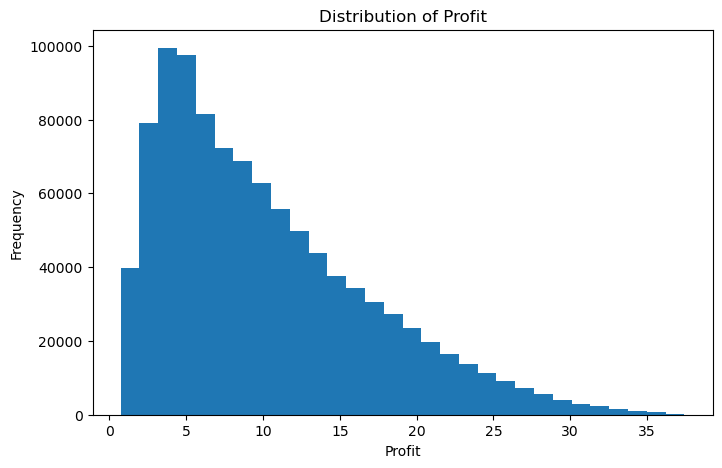

In [4]:
plt.figure(figsize=(8,5))
plt.hist(masterDataset['profit'], bins=30)
plt.title('Distribution of Profit')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.show()

**Explanation:** The histogram showed that most orders fell within the lower profit ranges. The number of orders quickly increased near the beginning of the graph, peaked around 10,000, and then gradually decreased across the remaining bars. This suggests that very high-profit orders were less common in the dataset.

### Cleaning the Data
Several unnecessary columns were removed from the dataset before training the models. Identifier-based columns such as order_id, store_id, and customer_id were excluded because they don't contribute anything for our predictions. Additional columns that could introduce noise or inconsistencies were also removed to help improve model performance and reduce the risk of data leakage.

#### When making target cuts we considered cutting out data that falls into these 3 categories:
1. The target so what we're trying to figure out. In this case we are trying to figure out if a product will be high profit or not. Anything that would reveal or leak this information to the model was considered to be cut
2. Useless identifiers like the store ID, ProdID, CustomerID etc. this doesn't really help in knowing if a product is high profit
3. Features that might just add noise. City should be dropped because it's inaccurate. Country has a argument to keep but could be added noise so something like join_date is irrelevant

In [5]:
columnsToDrop = [
    "order_id",
    "store_id",
    "product_id",
    "customer_id",
    "city",
    "join_date"
]
masterDataset = masterDataset.drop(columns=columnsToDrop)
print(masterDataset.shape)
print(masterDataset.columns.tolist())
masterDataset.head(10)

(1000000, 18)
['order_date', 'quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit', 'product_name', 'brand', 'category', 'cocoa_percent', 'weight_g', 'store_name', 'country', 'store_type', 'age', 'gender', 'loyalty_member']


,order_date,quantity,unit_price,discount,revenue,cost,profit,product_name,brand,category,cocoa_percent,weight_g,store_name,country,store_type,age,gender,loyalty_member
0,2023-01-07,5,14.43,0.15,61.33,42.77,18.56,Praline Chocolate 70%,Hershey,White,70.0,200.0,Chocolate Store 93,UK,Airport,44,Male,1
1,2023-10-22,3,12.01,0.00,36.03,19.06,16.97,Dark Chocolate 60%,Lindt,Praline,60.0,50.0,Chocolate Store 65,Australia,Retail,63,Female,1
2,2023-05-07,2,10.02,0.00,20.04,10.29,9.75,Milk Chocolate 90%,Hershey,Milk,90.0,50.0,Chocolate Store 78,UK,Airport,35,Male,1
3,2024-06-23,2,14.66,0.10,26.39,16.35,10.04,Dark Chocolate 60%,Godiva,Praline,60.0,50.0,Chocolate Store 88,USA,Retail,37,Female,1
4,2024-09-24,1,12.34,0.00,12.34,7.94,4.40,Truffle Chocolate 90%,Hershey,Truffle,90.0,120.0,Chocolate Store 54,Canada,Online,57,Female,0
5,2024-03-29,4,13.52,0.00,54.08,36.59,17.49,Praline Chocolate 90%,Hershey,Dark,90.0,100.0,Chocolate Store 89,Canada,Online,35,Male,0
6,2023-02-26,1,11.97,0.10,10.77,7.16,3.61,Truffle Chocolate 80%,Mars,Dark,80.0,120.0,Chocolate Store 24,France,Online,55,Female,0
7,2023-11-03,5,4.62,0.00,23.10,16.15,6.95,White Chocolate 80%,Cadbury,Dark,80.0,50.0,Chocolate Store 85,USA,Online,36,Female,0
8,2024-10-11,4,7.88,0.00,31.52,19.90,11.62,White Chocolate 80%,Godiva,Praline,80.0,200.0,Chocolate Store 29,Australia,Online,63,Female,1
9,2023-12-17,3,8.88,0.00,26.64,18.19,8.45,White Chocolate 90%,Cadbury,Milk,90.0,120.0,Chocolate Store 56,Germany,Online,26,Female,0


In [6]:
threshold = masterDataset['profit'].quantile(0.75)
print('threshold:', threshold)

masterDataset['high_profit'] = (masterDataset['profit'] > threshold).astype(int)
print(masterDataset['high_profit'].value_counts())
print(masterDataset['high_profit'].value_counts(normalize=True))
print(masterDataset.columns.tolist())

threshold: 14.17
high_profit
0    750077
1    249923
Name: count, dtype: int64
high_profit
0    0.750077
1    0.249923
Name: proportion, dtype: float64
['order_date', 'quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit', 'product_name', 'brand', 'category', 'cocoa_percent', 'weight_g', 'store_name', 'country', 'store_type', 'age', 'gender', 'loyalty_member', 'high_profit']


### High Profit vs Low Profit
The dataset was divided into high-profit and low-profit classes using the 75th percentile of the profit column as the threshold. Orders above the threshold were labeled as high profit, while the remaining orders were labeled as low profit. This was to help visualize the class distribution, with 0 being low-profit and 1 being high-profit.

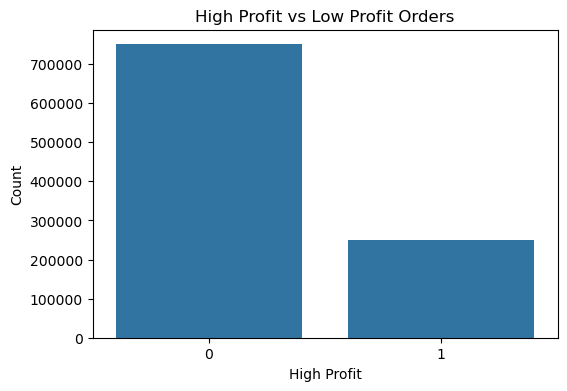

In [7]:
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(x='high_profit', data=masterDataset)
plt.title('High Profit vs Low Profit Orders')
plt.xlabel('High Profit')
plt.ylabel('Count')

plt.show()

#### Cutting any data leak columns that fall into category 1 of our list above

In [8]:
# Removing the target variable and any columns that could lead to data leakage

dataLeakColumnsToDrop = [
    "profit",
    "cost",
    "revenue"
]
masterDataset = masterDataset.drop(columns=dataLeakColumnsToDrop)
print(masterDataset.shape)
print(masterDataset.columns.tolist())
masterDataset.head(10)

(1000000, 16)
['order_date', 'quantity', 'unit_price', 'discount', 'product_name', 'brand', 'category', 'cocoa_percent', 'weight_g', 'store_name', 'country', 'store_type', 'age', 'gender', 'loyalty_member', 'high_profit']


,order_date,quantity,unit_price,discount,product_name,brand,category,cocoa_percent,weight_g,store_name,country,store_type,age,gender,loyalty_member,high_profit
0,2023-01-07,5,14.43,0.15,Praline Chocolate 70%,Hershey,White,70.0,200.0,Chocolate Store 93,UK,Airport,44,Male,1,1
1,2023-10-22,3,12.01,0.00,Dark Chocolate 60%,Lindt,Praline,60.0,50.0,Chocolate Store 65,Australia,Retail,63,Female,1,1
2,2023-05-07,2,10.02,0.00,Milk Chocolate 90%,Hershey,Milk,90.0,50.0,Chocolate Store 78,UK,Airport,35,Male,1,0
3,2024-06-23,2,14.66,0.10,Dark Chocolate 60%,Godiva,Praline,60.0,50.0,Chocolate Store 88,USA,Retail,37,Female,1,0
4,2024-09-24,1,12.34,0.00,Truffle Chocolate 90%,Hershey,Truffle,90.0,120.0,Chocolate Store 54,Canada,Online,57,Female,0,0
5,2024-03-29,4,13.52,0.00,Praline Chocolate 90%,Hershey,Dark,90.0,100.0,Chocolate Store 89,Canada,Online,35,Male,0,1
6,2023-02-26,1,11.97,0.10,Truffle Chocolate 80%,Mars,Dark,80.0,120.0,Chocolate Store 24,France,Online,55,Female,0,0
7,2023-11-03,5,4.62,0.00,White Chocolate 80%,Cadbury,Dark,80.0,50.0,Chocolate Store 85,USA,Online,36,Female,0,0
8,2024-10-11,4,7.88,0.00,White Chocolate 80%,Godiva,Praline,80.0,200.0,Chocolate Store 29,Australia,Online,63,Female,1,0
9,2023-12-17,3,8.88,0.00,White Chocolate 90%,Cadbury,Milk,90.0,120.0,Chocolate Store 56,Germany,Online,26,Female,0,0


In [9]:
# Remove order_date to no longer be a string
masterDataset['order_date'] = pd.to_datetime(masterDataset['order_date'])

masterDataset['order_month'] = masterDataset['order_date'].dt.month
masterDataset['order_dayofweek'] = masterDataset['order_date'].dt.dayofweek

masterDataset = masterDataset.drop(columns=['order_date'])

In [10]:
# Encode Categorical Columns
masterDataset = pd.get_dummies(
    masterDataset,
    drop_first=True
)

In [11]:
# Separate features and target
X = masterDataset.drop(columns=['high_profit'])
y = masterDataset['high_profit']

## Creating Train/Test Split
The dataset was split into training and testing sets using an 80/20 ratio. The training set was used to train the models, while the testing set evaluated performance on unseen data. Missing values were removed before training because the Gradient Boosting classifier could not process NaN values directly. Later on we will further split the dataset for validation to support our hyperparameter tuning on Gradient Boosting

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Combine train
trainCombined = X_train.copy()
trainCombined['target'] = y_train
trainCombined = trainCombined.dropna()

X_train = trainCombined.drop(columns=['target'])
y_train = trainCombined['target']

# Combine test
testCombined = X_test.copy()
testCombined['target'] = y_test
testCombined = testCombined.dropna()

X_test = testCombined.drop(columns=['target'])
y_test = testCombined['target']


### Running Models

In [13]:
# RandomForest
rfModel = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# GradientBoosting
gbModel = GradientBoostingClassifier(
    random_state=42
)

# fit both models
rfModel.fit(X_train, y_train)
gbModel.fit(X_train, y_train)

# predict
rfPredictions = rfModel.predict(X_test)
gbPredictions = gbModel.predict(X_test)

In [14]:
#Evaluation Random Forests
from sklearn.metrics import classification_report, accuracy_score

print ("Random Forest Accuracy:")
print(accuracy_score(y_test, rfPredictions))

print ("\nRandom Forest Classification Report:")
print(classification_report(y_test, rfPredictions))

Random Forest Accuracy:
0.9377209105047363

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96    148427
           1       0.88      0.87      0.87     49617

    accuracy                           0.94    198044
   macro avg       0.92      0.91      0.92    198044
weighted avg       0.94      0.94      0.94    198044



In [15]:
#Evaluation Gradient Boosting

print ("Gradient Boosting Accuracy:")
print(accuracy_score(y_test, gbPredictions))

print ("\nGradient Boosting Classification Report:")
print(classification_report(y_test, gbPredictions))

Gradient Boosting Accuracy:
0.9393922562662843

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96    148427
           1       0.87      0.89      0.88     49617

    accuracy                           0.94    198044
   macro avg       0.92      0.92      0.92    198044
weighted avg       0.94      0.94      0.94    198044



### Comparison between the two models

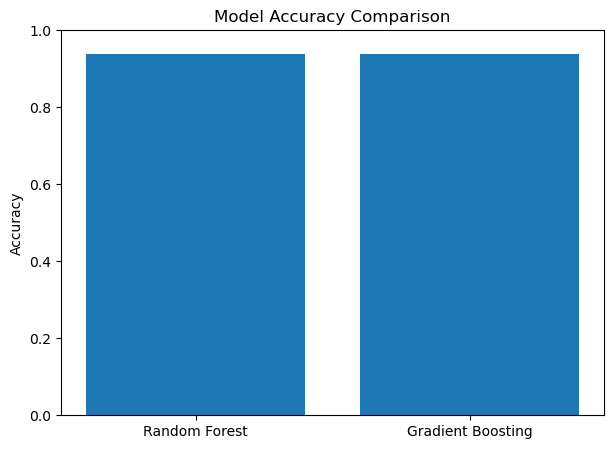

In [16]:
rfAccuracy = accuracy_score(y_test, rfPredictions)
gbAccuracy = accuracy_score(y_test, gbPredictions)

models = ['Random Forest', 'Gradient Boosting']
accuracies = [rfAccuracy, gbAccuracy]

plt.figure(figsize=(7,5))
plt.bar(models, accuracies)
plt.ylim(0,1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()

### Discussion on Model Comparison:

Both the Random Forest and Gradient Boosting models performed very well, with accuracies of approximately 93.7% and 93.9%. The results were very close overall, which likely means that both models were able to identify patterns within the dataset. However, the Gradient Boosting model consistently performed slightly better, specifically in recall for the high-profit class. This indicates that Gradient Boosting was slightly more effective at correctly identifying profitable orders.

One possible reason for the higher performance of Gradient Boosting is that it builds trees sequentially, allowing each new tree to correct errors made by the previous one. In contrast, Random Forest builds many independent trees and averages their results. Because of this, Gradient Boosting may capture more subtle relationships between features such as unit price, quantity, and discount. Although the improvement was pretty small, the comparison shows how different machine learning approaches can produce slightly different outcomes even when trained on the same data.

Through this exploration, it became clear that feature selection, data cleaning, and model choice all have a significant impact on prediction accuracy. The project also demonstrated how tree-based models can identify important business patterns within large datasets while still maintaining strong overall performance

## Confusion Matrix Between Models:
Using ConfusionMatrixDisplay.fromPrediction() for more info see: [ConfusionMatrixDisplay.fromPrediction()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay.from_predictions)

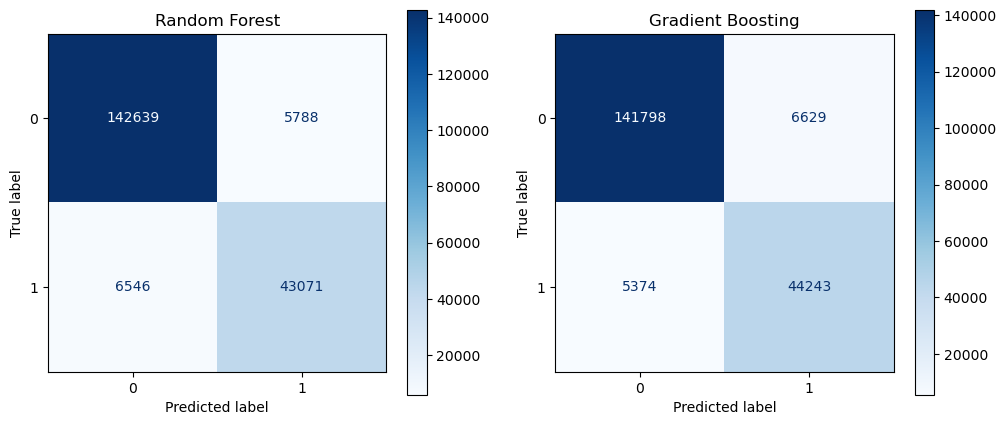

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, rfPredictions, ax=axes[0], cmap='Blues'
)
axes[0].set_title('Random Forest')

ConfusionMatrixDisplay.from_predictions(y_test, gbPredictions, ax=axes[1], cmap='Blues')
axes[1].set_title('Gradient Boosting')

plt.show()


### Discussion on confusion matrix:
**What does this confusion matrix represent?**
This confusion matrix breaks down a predictions into four categories and helps us see what kinds of mistakes the models made: 
* True negatives (top left) meaning the model correctly predicted not high profit and it was in fact not high profit
* False positives (top right) predicted high profit but made a mistake as it wasn't high profit meaning it's incorrect
* False negatives (bottom left) said it was not high profit when in reality it was actually a high profit
* True positives (bottom-right) correctly predicted high profit and the result is high profit

Both models produce very similar confusion matricess. Random Forest correctly classified 142,639 True Negatives and 43,071 True Positives. While Gradient Boosting correctly classified 141,798 True Negatives and 44,243 True Positives. The two models trade off in different ways: 
* Random Forest makes fewer false positives (5,788 vs 6,629), meaning it is slightly better about classifying as high profit. Gradient Boosting makes fewer false negatives (5,374 vs 6,546) meaning it catches slightly more of the true high profit classifications.


If we were to go off the benefits of using a machine learning model like this if you own a store and sell chocolate, then this matrix is helpful. If missing a high profit opportunity hurts more than a false alarm where you think a product is high profit when it actually isn't, then Gradient Boosting behavior would be preferable but if false alarms really hurt the store in profits and money then Random Forest's behavior would be better.

## Hyperparameter Exploration on Gradient Boosting Model:

**Why does hyperparameter tuning matter?**
* Hyperparameters are settings/sliders we choose before training begins. They define the behavior of the model. How complex it can be or how aggresive it learns. We like to think of it like an instrument that needs calibration before it's played. Theres no wrong way to calibrate your guitar as the user can alter it to whatever they think sounds best for the job. But with each change theres tradeoffs that are made in other areas. Maybe with a guitar the feeling or stiffness of the cords is a tradeoff or how much bass is present minimizes. It's up[ to the user to make the decision of what they might be willing to tradeoff in order to achieve the desired output. So in this case, the right hyperparameters can be the difference between a model that accurately catches patterns in the data and one that fails to learn anything meaningful at all and just displays information that we already know
* For Gradient Boosting specifically, hyperparameter tuning is important because the algorithm builds trees where each tree corrects the errors of the previous ones. Without proper tuning, Gradient Boosting can easily overfit or underfit.
* We chose to explore three hyperparameters: **n_estimators**, **learning_rate**, and **max_depth** because they are seen as the biggest controllers in Gradient Boosting. Other hyperparameters exist like subsample, min_samples_split, and min_samples_leaf, but the ones we chose are the most strong in determining how the model balances learning.

#### Creating Train/Validation/Test split for data

In [18]:
from sklearn.model_selection import train_test_split

# make a validation set out of the existing training data
X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Drop NaNs from training set
trainCombined = X_train.copy()
trainCombined['target'] = y_train
trainCombined = trainCombined.dropna()
X_train = trainCombined.drop(columns=['target'])
y_train = trainCombined['target']

# Drop NaNs from validation set too
valCombined = X_validation.copy()
valCombined['target'] = y_validation
valCombined = valCombined.dropna()
X_validation = valCombined.drop(columns=['target'])
y_validation = valCombined['target']

# make a sample dataset for hyperparameter tuning because just takes too long to run the full dataset everytime
X_training_sample = X_train.sample(n=100000, random_state=42)
y_training_sample = y_train.loc[X_training_sample.index]

print('Tuning subsample:', X_training_sample.shape)
print('Training subset:', X_train.shape)
print('Validation set: ', X_validation.shape)


Tuning subsample: (100000, 150)
Training subset: (633753, 150)
Validation set:  (158439, 150)


### Experimenting With Different n_estimators:

**What does n_estimators do?**
- The n_estimators (number of trees) parameter controls how many trees are added to the ensemble. Each tree corrects the errors of the tree before it. More trees mean more help or ability to spot tougher patterns, but this comes at a cost. Beyond a certain point, if you add too much trees the model will stop improving validation accuracy and instead begin memorizing noise in the training data. But also if n_estimators is too low, the model underfits and fails to spot any meaningful patterns. Basically just relays information that we already knew before running the model. If it is too high, training time will increase  and the model becomes prone to overfitting. Choosing the right number of trees is an important tradeoff that ran throughout the course when we would talk about bias variance.

n_estimators=10: train=0.9277, validationAccuracy=0.9262
n_estimators=25: train=0.9375, validationAccuracy=0.9368
n_estimators=50: train=0.9407, validationAccuracy=0.9394
n_estimators=100: train=0.9413, validationAccuracy=0.9401
n_estimators=200: train=0.9426, validationAccuracy=0.9401
n_estimators=300: train=0.9435, validationAccuracy=0.9400


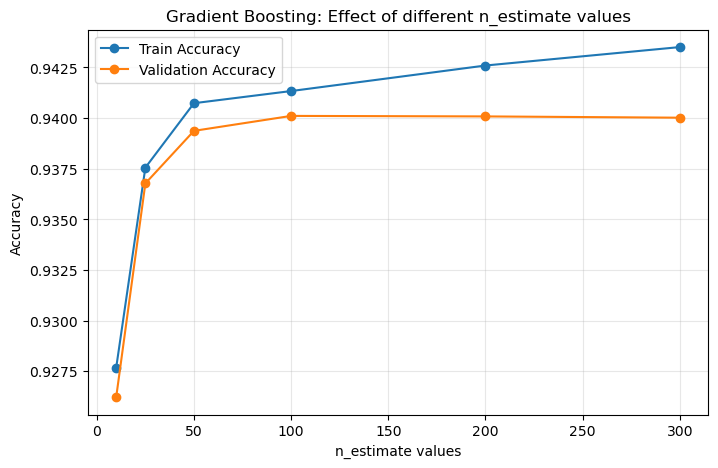

In [19]:
from sklearn.ensemble import GradientBoostingClassifier
nEstimatorsValues = [10, 25, 50, 100, 200, 300]
trainingAccuracy = []
validationAccuracy = []

for n in nEstimatorsValues:
    gbModel = GradientBoostingClassifier(n_estimators=n, random_state=42)
    gbModel.fit(X_training_sample, y_training_sample)
    trainingAccuracy.append(gbModel.score(X_training_sample, y_training_sample))
    validationAccuracy.append(gbModel.score(X_validation, y_validation))
    print(f'n_estimators={n}: train={trainingAccuracy[-1]:.4f}, validationAccuracy={validationAccuracy[-1]:.4f}')

plt.figure(figsize=(8,5))
plt.plot(nEstimatorsValues, trainingAccuracy, marker='o', label='Train Accuracy')
plt.plot(nEstimatorsValues, validationAccuracy, marker='o', label='Validation Accuracy')
plt.xlabel('n_estimate values')
plt.ylabel('Accuracy')
plt.title('Gradient Boosting: Effect of different n_estimate values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Discussion of n_estimators Experiment Results:
As you can see, The results of increasing n_estimators increases and makes a huge jump at first in validation accuracy. But as we go on we can see that as it increases it begins to mess with the model more than help it. Around ~150 n_estimators is when the overfitting can be seen taking effect. While 100 n_estimators shows our sweet spot. Notice that the training accuracy shows much better results as n_estimators increases but these results don't reflect in the Validation Accuracy as when the model is actually tested on somewhat unseen data it overfits big time and struggles. So don't be fooled by the spectacular training accuracy at 300 n_estimators because when it came to quiz it, it ended up doing worse than when the model had less trees.

### Experimenting With Different learning_rates:

**What does learning_rates do?**
- The learning_rate controls how much each new tree contributes to the overall prediction. A high learning rate means each tree makes big corrections which allows the model to learn quickly but also increases the risk of overfitting. A low learning rate makes each tree contribution small and which improves catching detailed patterns but requires more trees.

learningRates=0.01: train=0.9136, validationAccuracy=0.9139
learningRates=0.05: train=0.9409, validationAccuracy=0.9398
learningRates=0.1: train=0.9413, validationAccuracy=0.9401
learningRates=0.2: train=0.9424, validationAccuracy=0.9402
learningRates=0.5: train=0.9456, validationAccuracy=0.9391
learningRates=1.0: train=0.9476, validationAccuracy=0.9362


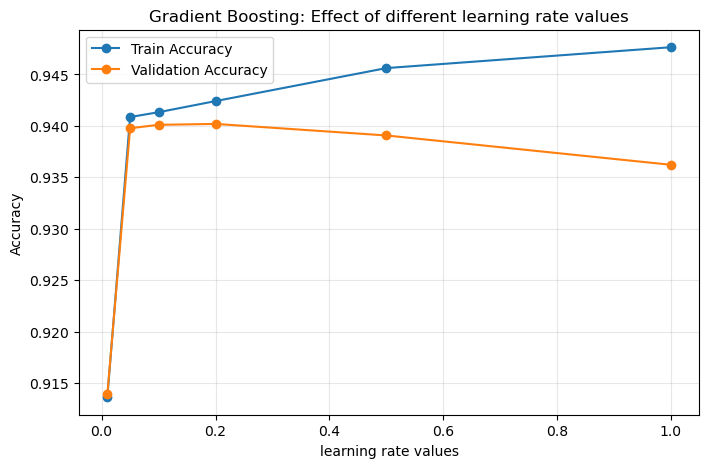

In [20]:
from sklearn.ensemble import GradientBoostingClassifier
learningRates = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
trainingAccuracy = []
validationAccuracy = []

for LR in learningRates:
    gbModel = GradientBoostingClassifier(learning_rate=LR, random_state=42)
    gbModel.fit(X_training_sample, y_training_sample)
    trainingAccuracy.append(gbModel.score(X_training_sample, y_training_sample))
    validationAccuracy.append(gbModel.score(X_validation, y_validation))
    print(f'learningRates={LR}: train={trainingAccuracy[-1]:.4f}, validationAccuracy={validationAccuracy[-1]:.4f}')

plt.figure(figsize=(8,5))
plt.plot(learningRates, trainingAccuracy, marker='o', label='Train Accuracy')
plt.plot(learningRates, validationAccuracy, marker='o', label='Validation Accuracy')
plt.xlabel('learning rate values')
plt.ylabel('Accuracy')
plt.title('Gradient Boosting: Effect of different learning rate values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Discussion of learning_rate Experiment Results:
As you can see, The results of increasing learning_rate increases and makes a huge jump at first in Validation Accuracy. But as we go on we can see that as it increases it begins to mess with the model more than help it. Around ~0.05 to 0.2 is where learning_rate does best. Something to notice is the huge disparity that forms between training and validation accuracy once learning_rate hits ~0.3. This was not seen in our previous experiment in n_estimators. This might be soley due to trees needed as learning_rate goes up. As mentioned above when learning_rate goes up so does the needed trees and we can see that validation accuracy just takes a hit as the values increase. So tree availability is probably the biggest factor in this. Also notice that the training accuracy shows much better results as learning_rate increases but these results don't reflect in the Validation Accuracy as when the model is actually tested on somewhat unseen data it overfits big time and struggles. So similar to n_estimators don't be fooled by the strong training accuracy at 1.0 learning_rate. 

### Experimenting With Different max_depth:

**What does max_depth do?**
- The max_depth controls how deep each individual tree can grow. The more short the trees are results in weak learners that capture only basic patterns. Deeper trees are more detailed but a downside is that it can memorize specific training patterns which can leads to overfitting. Tuning max_depth controls how much work each individual tree does.

maxDepth value=1: train=0.9364, validationAccuracy=0.9357
maxDepth value=2: train=0.9411, validationAccuracy=0.9400
maxDepth value=3: train=0.9413, validationAccuracy=0.9401
maxDepth value=5: train=0.9445, validationAccuracy=0.9399
maxDepth value=7: train=0.9533, validationAccuracy=0.9387
maxDepth value=10: train=0.9817, validationAccuracy=0.9364


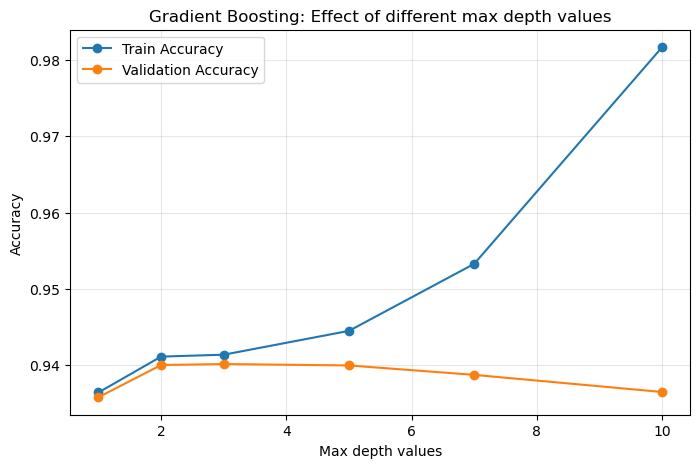

In [21]:
maxDepthValues = [1, 2, 3, 5, 7, 10]
trainingAccuracy = []
validationAccuracy = []

for MD in maxDepthValues:
    gbModel = GradientBoostingClassifier(max_depth=MD, random_state=42)
    gbModel.fit(X_training_sample, y_training_sample)
    trainingAccuracy.append(gbModel.score(X_training_sample, y_training_sample))
    validationAccuracy.append(gbModel.score(X_validation, y_validation))
    print(f'maxDepth value={MD}: train={trainingAccuracy[-1]:.4f}, validationAccuracy={validationAccuracy[-1]:.4f}')

plt.figure(figsize=(8,5))
plt.plot(maxDepthValues, trainingAccuracy, marker='o', label='Train Accuracy')
plt.plot(maxDepthValues, validationAccuracy, marker='o', label='Validation Accuracy')
plt.xlabel('Max depth values')
plt.ylabel('Accuracy')
plt.title('Gradient Boosting: Effect of different max depth values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Discussion of max_depth Experiment Results:
As you can see, The results of increasing max_depth increases at first in Validation Accuracy but not the same increase we saw in the other two hyperparamters when tested independently. But as usual, as we go on we can see it begins to mess with the model more than help it. Around 2-3 is where learning_rate does best. Again another note to notice is the huge disparity that forms between training and validation accuracy once max_depth hits 6. This jump in disparity is seen in learning_rate but not n_estimators. Also notice that the training accuracy shows much better results as max_depth increases but these results don't reflect in the Validation Accuracy as when the model is actually tested on somewhat unseen data it overfits big time and struggles. So similar to n_estimators don't be fooled by the strong training accuracy at 10. 

### Observations Seen Accross All 3 Experiments:
In all 3 hyperparameter experiments we saw a common pattern of overfitting as the value increases and a jump with the first value of the hyperparameter displaying the importance of having a value there to begin with. One thing noticed is the disparity jump between training accuracy and validation accuracy seen when max_depth and learning_rate increases but this huge disparity was not seen in n_estimators. With all 3 experiments we found our "sweet spots" max out at about ~0.938 in accuracy which leads us to think that this might be a cieling of potential that the model hits. We discussed in class how these models have a certain extent to how accurate they can be and theres almost like a cieling that is hit at some point. It seems with the common trend of capping out at 0.938 we reach that max which led us to predict that with all 3 hyperparameters combined into one model we will produce similar result. Let's put that prediction to the test.


## Now lets take the best hyperparameter results and combine them into one model on the full dataset and look at the results

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Combine train
trainCombined = X_train.copy()
trainCombined['target'] = y_train
trainCombined = trainCombined.dropna()

X_train = trainCombined.drop(columns=['target'])
y_train = trainCombined['target']

# Combine test
testCombined = X_test.copy()
testCombined['target'] = y_test
testCombined = testCombined.dropna()

X_test = testCombined.drop(columns=['target'])
y_test = testCombined['target']


In [23]:
from sklearn.metrics import classification_report, accuracy_score
# GradientBoosting
gbModel = GradientBoostingClassifier(max_depth=3, learning_rate=0.1, n_estimators=100, random_state=42)

gbModel.fit(X_train, y_train)

gbPredictions = gbModel.predict(X_test)

# Evaluation of fine tuned Gradient Boosting model

print ("Gradient Boosting Accuracy:")
print(accuracy_score(y_test, gbPredictions))

print ("\nGradient Boosting Classification Report:")
print(classification_report(y_test, gbPredictions))

Gradient Boosting Accuracy:
0.9393922562662843

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96    148427
           1       0.87      0.89      0.88     49617

    accuracy                           0.94    198044
   macro avg       0.92      0.92      0.92    198044
weighted avg       0.94      0.94      0.94    198044



### Observation of Results:
After hyperparameter tuning, our Gradient Boosting model got a test accuracy of 93.94% compared to 93.93% with default hyperparameters. An improvement of about 0.01 percentage points. While this gain is so small it is informative. After we looked into the Sklearn's [sklearn.ensemble.GradientBoostingClassifier()](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) default hyperparameters appear to be strong for our dataset and our exploration confirmed that the values we chose resemble within the ranges we tested. The validation curves above show that accuracy can dip quickly as model hyperparameter increases. Meaning the datasets ceiling is basically reached with just the default settings. Improving accuracy more from here would probably mean we would need to mess with the dataset and manipulate it more as that would do more than just tampering with the hyperparameters.

In [24]:

results = pd.DataFrame({
    'Model': ['Random Forest (baseline)', 'Gradient Boosting (Not Fine Tuned)', 'Gradient Boosting (Fine Tuned)'],
    'Accuracy': [0.9377209105047363,0.9393922562662843, 0.9394377007129728]
})
results

,Model,Accuracy
0,Random Forest (baseline),0.937721
1,Gradient Boosting (Not Fine Tuned),0.939392
2,Gradient Boosting (Fine Tuned),0.939438


## Feature Importance
Feature importance was analyzed using both the Random Forest and Gradient Boosting models to determine which variables were more important for predictions. The Random Forest model showed that quantity and unit_price were the most important features, with the remaining features being gradually less important. The Gradient Boosting model placed almost all importance on unit_price, quantity, and discount, while the other features aren't seen. This suggests that the Gradient Boosting model relied more heavily on a smaller set of more influential variables.

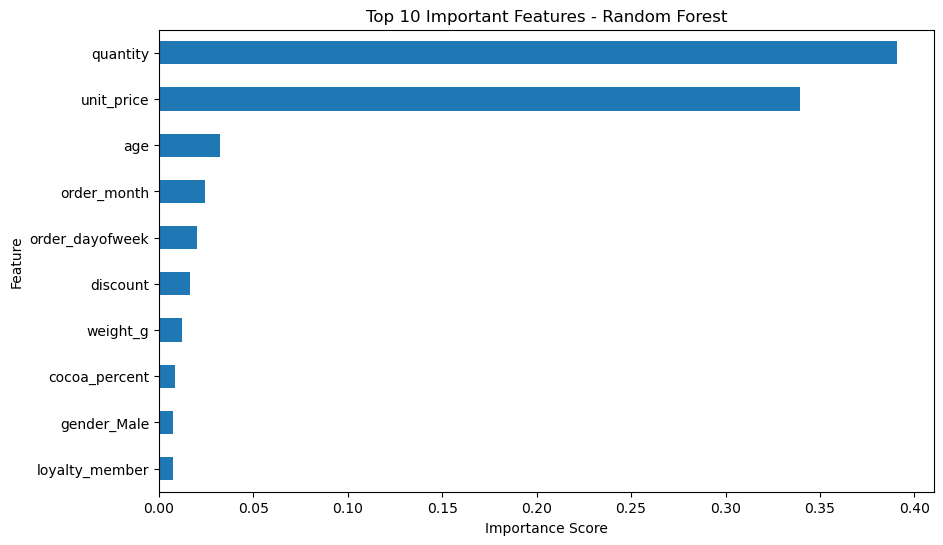

In [25]:
import pandas as pd

# Random Forest Feature Importance
featureImportance = pd.Series(
    rfModel.feature_importances_,
    index=X.columns
)

featureImportance = featureImportance.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
featureImportance.plot(kind='barh')
plt.title('Top 10 Important Features - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.show()

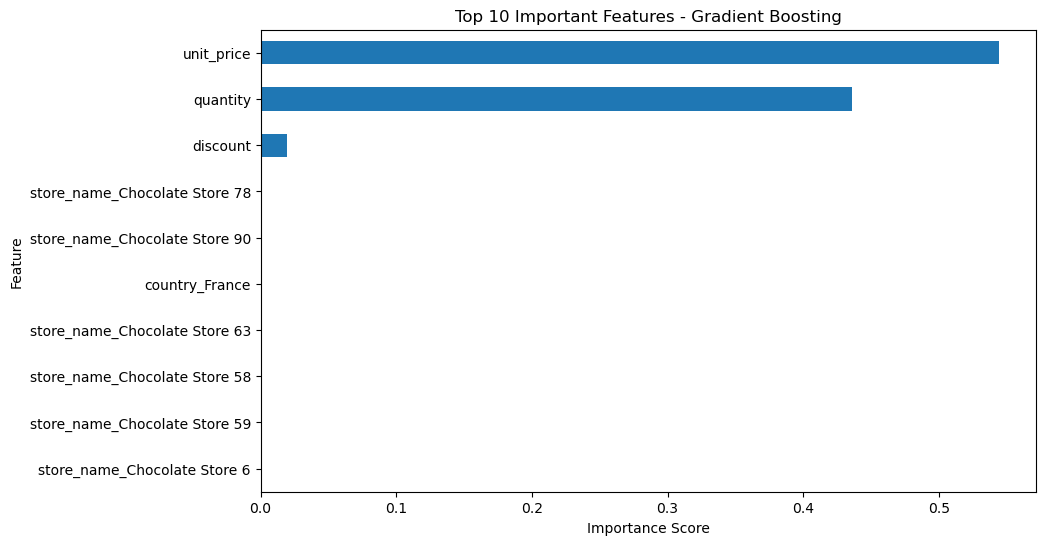

In [26]:
# Gradient Boosting Feature Importance

featureImportanceGB = pd.Series(
    gbModel.feature_importances_,
    index=X.columns
)

featureImportanceGB = featureImportanceGB.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
featureImportanceGB.plot(kind='barh')
plt.title('Top 10 Important Features - Gradient Boosting')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.show()

## Conclusion
Through this project we got to use the Chocolate Sales Dataset to predict wheather a product has potential to be seen as high profit or not. Through this project we learned how to think in a data driven way where we analyzed and determined how we can make the best use of the data given to us. This was arguabley the biggest challenge through the project as having an inclination on wheather a feature is important or not and what might mess up our analysis was not an easy task. The data prep was something we haven't really gotten to do in practice through the semester so getting the chance to work through that challenge was a good learning process. We also learned how to effectively split the data into train/test/and validation and effectively use it with the models and experiment was also a great opportunity. Working with data of this size really puts into persepctive what goes into the training and testing process of a model and made we can imagine that as the data amount increases with bigger projects and such the amount of data that needs to be processed and trained is hefty. We also learned how to effectivley discuss and analyze our results through words and visuals and figure out how to best use these tools and libraries to our advantage. Finally, we got to also test out the validation process and see the physical effects that a hyperparameter has on the model and understand in what ways the hyperparameter plays a role on the model. Although the results of our models wer overall miniscule compared to each other it was a great learning opportunity to just compare the models and see what goes into making the puzzle fit togehter. Seeing the overall tradeoffs of each decision and how the models might be making incorrect calls with false positives and false negatives provided clearer understanding for us and growth in our knowledge when it comes to the fundamentals of machine learning. Thank you for reading through our notebook!


## Sources Cited

* CS345 Notebooks (Very helpful throughout this project!)
* [Gradient Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html)
* [Confusion Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay.from_predictions)
* [GeeksforGeeks Random Forests Algo](https://www.geeksforgeeks.org/machine-learning/random-forest-algorithm-in-machine-learning/)
* [GeeksforGeeks Gradient Boosting Algo](https://www.geeksforgeeks.org/machine-learning/ml-gradient-boosting/)
* [How to Tune Hyperparameters in Gradient Boosting Algo](https://www.geeksforgeeks.org/machine-learning/how-to-tune-hyperparameters-in-gradient-boosting-algorithm/)
* [Youtube Video On Splitting Train/Validate/Test Dataset](https://www.youtube.com/watch?v=ZblqTCFnH-M)
* [Basic Pandas Introduction](https://www.w3schools.com/python/pandas/pandas_intro.asp)
* [GeeksforGeeks Understanding Confusion Matrix](https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/)